In [ ]:
!pip install transformers

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
print("Loading Model and Tokenizer...")
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True)
print("Advanced Architecture Loaded!")

Loading Model and Tokenizer...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Advanced Architecture Loaded!


In [ ]:
print("\n--- Tokenization & Generation ---")
prompt = "Artificial intelligence in the future will"
# Convert the text prompt into mathematical token IDs
inputs = tokenizer(prompt, return_tensors="pt")
print(f"Input Tokens: {tokenizer.convert_ids_to_tokens(inputs.input_ids[0])}")

# Generate text using the model
outputs = model.generate(
    inputs.input_ids,
    max_new_tokens=20,
    do_sample=True,
    temperature=0.7,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"\nFinal Generated Text:\n{generated_text}")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



--- Tokenization & Generation ---
Input Tokens: ['Art', 'ificial', 'Ġintelligence', 'Ġin', 'Ġthe', 'Ġfuture', 'Ġwill']

Final Generated Text:
Artificial intelligence in the future will have the capacity to take over the world’s most powerful computer and a massive amount of technology


In [ ]:
# To visualize attention, we run a single forward pass of our prompt
with torch.no_grad():
    forward_pass = model(**inputs)

# Extract the attention matrices (Tuple of all layers)
attention_layers = forward_pass.attentions

# We will look at the last layer of the neural network, and its first "Attention Head"
last_layer_attention = attention_layers[-1]
head_attention = last_layer_attention[0, 0].numpy() # Shape: (Seq_Len, Seq_Len)

# Get the exact tokens for our graph labels
tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

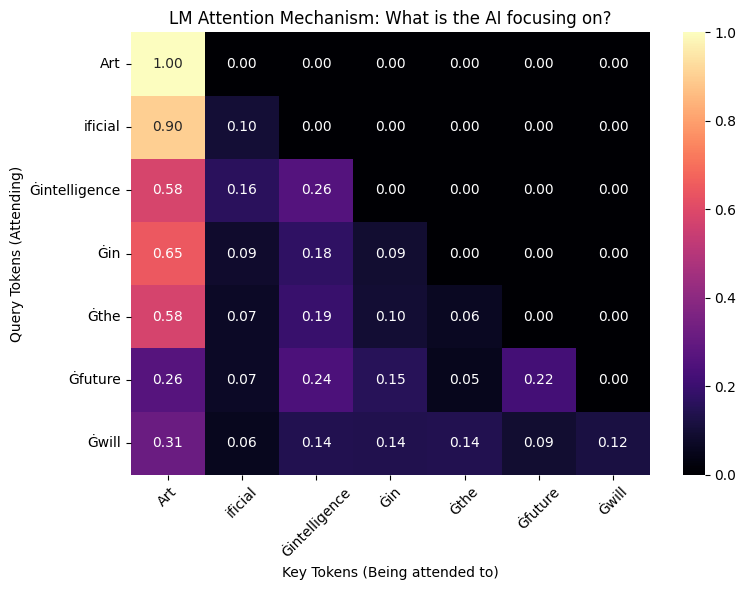

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(head_attention, xticklabels=tokens, yticklabels=tokens, cmap='magma', annot=True, fmt=".2f")
plt.title("LM Attention Mechanism: What is the AI focusing on?")
plt.xlabel("Key Tokens (Being attended to)")
plt.ylabel("Query Tokens (Attending)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()